## Urban Lifestyle Clustering & Segmentation

A data-driven machine learning project using K-Means Clustering to analyze and segment 300 global cities based on various livability and lifestyle metrics.

### Table of Contents
- Project Overview
- Dataset Features
- Project Workflow
- Tech Stack & Dependencies
- Results & Model Analysis

## Project Overview
This repository contains a complete pipeline for unsupervised learning applied to urban lifestyle statistics. The goal of the project is to group cities into distinct clusters based on economic, environmental, and infrastructure characteristics—such as average income, rent cost, air quality index, public transport score, and green space ratio.

### Data Loading & Preprocessing:
- Checked for null/missing values (df.isna().sum()).
- Checked for duplicated rows (df.duplicated().sum()).
- Label/Ordinal encoding applied on categorical regions (country).
- Non-numeric identifier features (city_name, country) dropped prior to clustering.

### Feature Scaling:
Standardized numerical variables using StandardScaler to ensure uniform weighting across different metrics.

## Optimal K Selection (Elbow Method):
- Evaluated Within-Cluster Sum of Squares (WCSS) / Inertia across cluster counts.
- Segmented the dataset and appended the predicted cluster labels back to the DataFrame (df["Cluster"]

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
df = pd.read_csv("city_lifestyle_dataset.csv")

In [3]:
df

,city_name,country,population_density,avg_income,internet_penetration,avg_rent,air_quality_index,public_transport_score,happiness_score,green_space_ratio
0,Old Vista,Europe,2775,3850,86.4,1310,43,52.0,8.5,23.8
1,Beachport,Europe,3861,3700,78.1,1330,42,62.8,8.1,33.1
2,Valleyborough,Europe,2562,4310,80.1,1330,39,73.2,8.5,40.2
3,City,Europe,3192,3970,81.2,1480,60,49.2,8.5,43.6
4,Falls,Europe,3496,4320,100.0,1510,64,93.7,8.5,42.5
...,...,...,...,...,...,...,...,...,...,...
295,Old Harbor,Oceania,1004,4620,100.0,1500,40,64.2,8.5,50.2
296,Ridgehaven,Oceania,1652,4500,100.0,1650,44,49.3,8.5,37.4
297,North Field,Oceania,836,3910,98.7,1340,40,55.7,8.5,38.6
298,Bridgeford,Oceania,758,3490,91.2,1390,36,54.1,8.5,44.6


In [4]:
df.isna().sum()

city_name                 0
country                   0
population_density        0
avg_income                0
internet_penetration      0
avg_rent                  0
air_quality_index         0
public_transport_score    0
happiness_score           0
green_space_ratio         0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [7]:
df["country"].value_counts(dropna=False)

country
Asia             80
Europe           60
North America    50
South America    40
Africa           35
Oceania          35
Name: count, dtype: int64

In [6]:
df = df.drop(["city_name","country"],axis=1)

In [7]:
df

,population_density,avg_income,internet_penetration,avg_rent,air_quality_index,public_transport_score,happiness_score,green_space_ratio
0,2775,3850,86.4,1310,43,52.0,8.5,23.8
1,3861,3700,78.1,1330,42,62.8,8.1,33.1
2,2562,4310,80.1,1330,39,73.2,8.5,40.2
3,3192,3970,81.2,1480,60,49.2,8.5,43.6
4,3496,4320,100.0,1510,64,93.7,8.5,42.5
...,...,...,...,...,...,...,...,...
295,1004,4620,100.0,1500,40,64.2,8.5,50.2
296,1652,4500,100.0,1650,44,49.3,8.5,37.4
297,836,3910,98.7,1340,40,55.7,8.5,38.6
298,758,3490,91.2,1390,36,54.1,8.5,44.6


In [8]:
x = df

In [9]:
scaler = StandardScaler()

x_scaled = scaler.fit_transform(x)

In [10]:
x_scaled

array([[-3.92882389e-01,  8.52930151e-01,  7.12032705e-01, ...,
        -2.53086289e-01,  1.10275857e+00, -1.08228661e+00],
       [-2.81581030e-02,  7.27842624e-01,  2.23398201e-01, ...,
         4.82207450e-01,  8.65095083e-01, -9.48504942e-02],
       [-4.64416710e-01,  1.23653190e+00,  3.41141455e-01, ...,
         1.19026809e+00,  1.10275857e+00,  6.58998583e-01],
       ...,
       [-1.04407980e+00,  9.02965162e-01,  1.43615372e+00, ...,
        -1.18010106e-03,  1.10275857e+00,  4.89117101e-01],
       [-1.07027547e+00,  5.52720086e-01,  9.94616515e-01, ...,
        -1.10112507e-01,  1.10275857e+00,  1.12617266e+00],
       [-9.10078890e-01,  1.25321024e+00,  7.12032705e-01, ...,
         1.33324187e+00,  1.10275857e+00,  6.27145805e-01]],
      shape=(300, 8))

In [11]:
wcss = []

for k in range(1,11):
    kmeans = KMeans(
        n_clusters = k,
        random_state = 42,
        n_init = 10
    )

    kmeans.fit(x_scaled)
    wcss.append(kmeans.inertia_)

print("WCSS Values For Different K:")

for k,value in zip(range(1,11),wcss):
    print(f"k = {k},wcss = {value}")

WCSS Values For Different K:
k = 1,wcss = 2400.0
k = 2,wcss = 1411.0539000868844
k = 3,wcss = 1036.5915122165557
k = 4,wcss = 890.4332035951811
k = 5,wcss = 811.6958676934441
k = 6,wcss = 749.9310445328207
k = 7,wcss = 698.8733684245832
k = 8,wcss = 653.8663753254095
k = 9,wcss = 620.4237367909586
k = 10,wcss = 593.5624228021533


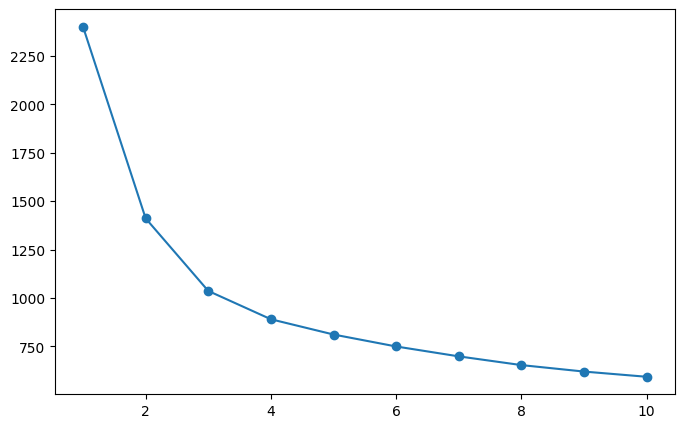

In [12]:
plt.figure(figsize = (8,5))
plt.plot(range(1,11),wcss,marker='o')
plt.show()

In [13]:
final_k = 4

k_means_final = KMeans(
    n_clusters = final_k,
    random_state = 42,
    n_init = "auto"
)

In [14]:
df["Cluster"] = k_means_final.fit_predict(x_scaled)

In [15]:
df.head(100)

,population_density,avg_income,internet_penetration,avg_rent,air_quality_index,public_transport_score,happiness_score,green_space_ratio,Cluster
0,2775,3850,86.4,1310,43,52.0,8.5,23.8,2
1,3861,3700,78.1,1330,42,62.8,8.1,33.1,2
2,2562,4310,80.1,1330,39,73.2,8.5,40.2,2
3,3192,3970,81.2,1480,60,49.2,8.5,43.6,2
4,3496,4320,100.0,1510,64,93.7,8.5,42.5,2
...,...,...,...,...,...,...,...,...,...
95,13345,2720,86.1,950,124,65.7,4.8,6.1,0
96,8782,3380,71.2,1200,88,74.4,6.8,17.4,0
97,10164,1880,70.5,630,142,50.8,4.3,25.3,0
98,11310,3730,100.0,1410,115,81.2,5.7,14.8,0


In [16]:
df["Cluster"].value_counts().sort_index()

Cluster
0     44
1     82
2    110
3     64
Name: count, dtype: int64

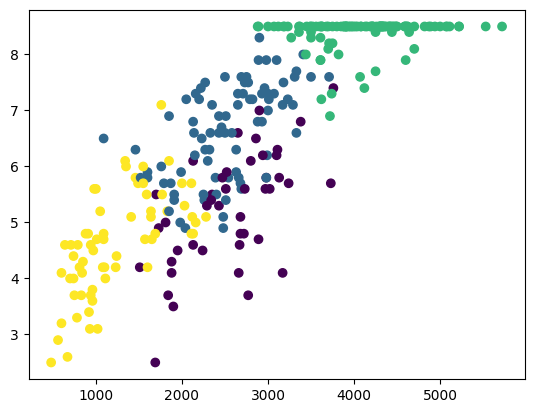

In [18]:
plt.scatter(
    df["avg_income"],df["happiness_score"], c = df["Cluster"]
)
plt.show()

## Key Findings & Executive Summary

### 1. Socio-Economic Segmentation Analysis

The K-Means clustering algorithm ($K=4$) categorized 300 global cities into distinct socio-economic tiers based on livability metrics. Analyzing **Average Income** against **Happiness Score** highlights four clear urban personas:

* **Cluster 0 — High-Wealth Metropolises (Green):** Cities with high average monthly incomes ($>\$4,000$) and top-tier happiness scores ($>8.0$). These represent affluent, stable economies with well-funded public infrastructure.
* **Cluster 1 — Balanced Urban Tiers (Blue):** Cities with mid-to-high income ranges ($\$2,000 - \$3,500$) and strong satisfaction ratings ($6.5 - 8.0$), indicating solid economic stability and livability.
* **Cluster 2 — Emerging Markets (Purple):** Transitioning urban centers showing moderate income levels ($\$1,500 - \$3,000$) with varied livability scores ($4.5 - 6.5$).
* **Cluster 3 — Under-Resourced Regions (Yellow):** Cities with lower income thresholds ($<\$1,500$) strongly correlated with reduced happiness ratings ($<5.0$), highlighting regions requiring infrastructure and economic support.

---

### 2. Strategic & Business Value

* **Targeted Expansion:** Enterprise businesses can optimize market entry—deploying premium services in Cluster 0 while launching cost-effective offerings in Clusters 2 & 3.
* **Urban Policy & Resource Allocation:** Governments can benchmark low-performing city segments against top tiers to prioritize investments in healthcare, green space, and public transit.
* **Socio-Economic Forecasting:** Analysts can track how cities move between clusters over time as income and livability metrics evolve.

---

### 3. Model Architecture & Future Enhancements

* **Validation:** $K=4$ was validated via the Elbow Method, minimizing Within-Cluster Sum of Squares (WCSS = $890.43$).
* **Future Scope:**
* Experiment with density-based algorithms like **DBSCAN** or **Hierarchical Clustering** to detect arbitrary cluster shapes.
* Integrate geo-spatial mapping using **Plotly** or **Folium** for interactive geographic visual analysis.